# Option Pricing Model (OPM) – Project Horizon Structured M&A Option

Values the Call/Put option structure between Olympus BV (call holder) and Titan (put holder).

## Key Contract Terms (from Option Agreement)
- **Option Shares:** 1,386,020 E ordinary shares
- **Call Option Period:** exercisable Year 3 – Year 5 from SPA Completion (Bermudan)
- **Put Option Period:** exercisable Year 3.5 – Year 6 from SPA Completion (Bermudan)
- **Strike = SPA price + Applicable Coupon** (step-up schedule, capitalised annually)
  - Call coupons: 2.75% / 3.00% / 3.00% / 4.20% / 4.20% (Years 0-1 through 4-5)
  - Put coupons:  2.75% / 3.00% / 3.00% / 4.10% / 4.10% / 4.10% (Years 0-1 through 5-6)
- **Pricing method:** Least-Squares Monte Carlo (Longstaff-Schwartz) for Bermudan exercise

## Simplifying Assumptions
- SPA price per share = 100 (placeholder; scale results to actual price)
- No Gaia leakage, no SPA claim adjustments, no dividends
- Risk-neutral drift = risk-free rate (standard option pricing)

## 1. Inputs

In [1]:
import numpy as np
from numpy.polynomial import polynomial as P

# ============================================================
# CONTRACT TERMS (from Option Agreement)
# ============================================================
TOTAL_EQUITY_USD = 3_200_000_000
OPTION_SHARES    = 1_386_020       # E ordinary shares (25% stake)
TOTAL_SHARES     = OPTION_SHARES / 0.25
SPA_price        = TOTAL_EQUITY_USD / TOTAL_SHARES   # USD per share

CALL_COUPONS = [0.0275, 0.0300, 0.0300, 0.0420, 0.0420]
PUT_COUPONS  = [0.0275, 0.0300, 0.0300, 0.0410, 0.0410, 0.0410]

call_start, call_end = 3.0, 5.0
put_start,  put_end  = 3.5, 6.0

# ============================================================
# MARKET / ECONOMIC ASSUMPTIONS
# ============================================================
# Asset volatility: unlevered equity vol, global KO bottler peers, Capital IQ c. 31-Dec-2025
# Peer average = 21.6%; rounded to nearest 25bps = 20.00%
asset_volatility = 0.20

# USD risk-free rate per Bloomberg at valuation date
risk_free_rate   = 0.04929

# ============================================================
# SIMULATION SETTINGS
# ============================================================
simulations    = 1_000_000
steps_per_year = 12
dt             = 1 / steps_per_year
total_years    = 6
total_steps    = int(total_years / dt) + 1

np.random.seed(42)
print(f"SPA price per share:        USD {SPA_price:,.2f}")
print(f"Option shares value at SPA: USD {SPA_price * OPTION_SHARES:,.0f}  (25% of ${TOTAL_EQUITY_USD/1e9:.1f}bn)")
print(f"Asset volatility:           {asset_volatility:.2%}")
print(f"Risk-free rate:             {risk_free_rate:.3%}")
print(f"Simulations:                {simulations:,}")
print("Inputs loaded.")

SPA price per share:        USD 577.19
Option shares value at SPA: USD 800,000,000  (25% of $3.2bn)
Asset volatility:           20.00%
Risk-free rate:             4.929%
Simulations:                1,000,000
Inputs loaded.


## 2. Build Strike Paths

Strike at time *t* = SPA price × ∏(1 + rᵢ) for completed years × (1 + r_current)^fractional_year.  
Separate schedules for call and put as per the Option Agreement.

In [2]:
def build_strike_path(SPA_price, coupons, total_steps, dt):
    """Annual compounding strike path using contract coupon schedule."""
    strike = np.zeros(total_steps)
    for step in range(total_steps):
        t        = step * dt
        yr_int   = int(t)
        frac     = t - yr_int
        acc      = SPA_price
        # Compound through completed years
        for y in range(min(yr_int, len(coupons))):
            acc *= (1 + coupons[y])
        # Partial-year accrual in current bucket (annually compounded)
        if yr_int < len(coupons):
            acc *= (1 + coupons[yr_int]) ** frac
        strike[step] = acc
    return strike

call_strike = build_strike_path(SPA_price, CALL_COUPONS, total_steps, dt)
put_strike  = build_strike_path(SPA_price, PUT_COUPONS,  total_steps, dt)

# Spot-check a few values
time_grid = np.arange(total_steps) * dt
for yr in [0, 1, 2, 3, 4, 5, 6]:
    idx = int(yr / dt)
    if idx < total_steps:
        print(f"Year {yr:3.1f} | Call strike: {call_strike[idx]:.4f} | Put strike: {put_strike[idx]:.4f}")

Year 0.0 | Call strike: 577.1922 | Put strike: 577.1922
Year 1.0 | Call strike: 593.0650 | Put strike: 593.0650
Year 2.0 | Call strike: 610.8570 | Put strike: 610.8570
Year 3.0 | Call strike: 629.1827 | Put strike: 629.1827
Year 4.0 | Call strike: 655.6084 | Put strike: 654.9792
Year 5.0 | Call strike: 683.1439 | Put strike: 681.8333
Year 6.0 | Call strike: 683.1439 | Put strike: 709.7885


## 3. Simulate Equity Value Paths (Risk-Neutral GBM)

Under the risk-neutral measure the equity drifts at the risk-free rate.

In [3]:
paths = np.zeros((simulations, total_steps))
paths[:, 0] = SPA_price

for t in range(1, total_steps):
    z = np.random.standard_normal(simulations)
    paths[:, t] = paths[:, t-1] * np.exp(
        (risk_free_rate - 0.5 * asset_volatility**2) * dt
        + asset_volatility * np.sqrt(dt) * z
    )

print(f"Simulated {simulations:,} paths × {total_steps} steps.")
print(f"Mean equity at Year 6: {paths[:, -1].mean():.2f}  (expect ~{SPA_price * np.exp(risk_free_rate * total_years):.2f} risk-neutral)")

Simulated 1,000,000 paths × 73 steps.
Mean equity at Year 6: 774.96  (expect ~775.82 risk-neutral)


## 4. Call Option – Bermudan LSM (Year 3–5)

Olympus BV holds the call: payoff = max(S − K_call, 0).  
We use Longstaff-Schwartz (LSM) regression to determine early exercise.

In [4]:
def lsm_bermudan_call(paths, strike_path, window_start, window_end, dt, risk_free_rate):
    """
    Longstaff-Schwartz LSM for a Bermudan call.
    Returns (per_share_value, payoff_std) where payoff_std is the std dev of
    discounted cash flows per share (used for standard error calculation).
    """
    idx_start = int(window_start / dt)
    idx_end   = int(window_end   / dt)
    discount  = np.exp(-risk_free_rate * dt)

    payoff_terminal = np.maximum(paths[:, idx_end] - strike_path[idx_end], 0)
    cash_flow = payoff_terminal.copy()

    for step in range(idx_end - 1, idx_start - 1, -1):
        cash_flow *= discount
        intrinsic = paths[:, step] - strike_path[step]
        itm = intrinsic > 0
        if itm.sum() < 5:
            continue
        S_itm  = paths[itm, step]
        cf_itm = cash_flow[itm]
        X = np.column_stack([np.ones(itm.sum()), S_itm, S_itm**2, S_itm**3])
        coeffs, _, _, _ = np.linalg.lstsq(X, cf_itm, rcond=None)
        continuation = X @ coeffs
        exercise = intrinsic[itm] > continuation
        idx_itm  = np.where(itm)[0]
        cash_flow[idx_itm[exercise]] = intrinsic[itm][exercise]

    discount_to_zero = np.exp(-risk_free_rate * window_start)
    cf_discounted = cash_flow * discount_to_zero
    return cf_discounted.mean(), cf_discounted.std()

call_value_per_share, call_payoff_std = lsm_bermudan_call(
    paths, call_strike, call_start, call_end, dt, risk_free_rate
)
print(f"Call value (per share): {call_value_per_share:>10.4f}")

Call value (per share):   118.1812


## 5. Put Option – Bermudan LSM (Year 3.5–6)

Titan holds the put: payoff = max(K_put − S, 0).  
From Olympus BV's perspective this is a **liability** (short put).

In [5]:
def lsm_bermudan_put(paths, strike_path, window_start, window_end, dt, risk_free_rate):
    """
    Longstaff-Schwartz LSM for a Bermudan put.
    Returns (per_share_value, payoff_std).
    """
    idx_start = int(window_start / dt)
    idx_end   = int(window_end   / dt)
    discount  = np.exp(-risk_free_rate * dt)

    payoff_terminal = np.maximum(strike_path[idx_end] - paths[:, idx_end], 0)
    cash_flow = payoff_terminal.copy()

    for step in range(idx_end - 1, idx_start - 1, -1):
        cash_flow *= discount
        intrinsic = strike_path[step] - paths[:, step]
        itm = intrinsic > 0
        if itm.sum() < 5:
            continue
        S_itm  = paths[itm, step]
        cf_itm = cash_flow[itm]
        X = np.column_stack([np.ones(itm.sum()), S_itm, S_itm**2, S_itm**3])
        coeffs, _, _, _ = np.linalg.lstsq(X, cf_itm, rcond=None)
        continuation = X @ coeffs
        exercise = intrinsic[itm] > continuation
        idx_itm  = np.where(itm)[0]
        cash_flow[idx_itm[exercise]] = intrinsic[itm][exercise]

    discount_to_zero = np.exp(-risk_free_rate * window_start)
    cf_discounted = cash_flow * discount_to_zero
    return cf_discounted.mean(), cf_discounted.std()

put_value_per_share, put_payoff_std = lsm_bermudan_put(
    paths, put_strike, put_start, put_end, dt, risk_free_rate
)
print(f"Put value  (per share): {put_value_per_share:>10.4f}")

Put value  (per share):    86.6643


## 6. Summary – Net Instrument Value

From **Olympus BV's** perspective:  
- Long Call (asset) + Short Put (liability)  
- Net = Call − Put

In [6]:
net_per_share = call_value_per_share - put_value_per_share

call_total = call_value_per_share * OPTION_SHARES
put_total  = put_value_per_share  * OPTION_SHARES
net_total  = net_per_share        * OPTION_SHARES

print("=" * 55)
print(f"  Assumptions: asset_vol={asset_volatility:.0%}, rf={risk_free_rate:.3%}, SPA=USD {SPA_price:,.2f}")
print("-" * 55)
print(f"  Call value   per share: USD {call_value_per_share:>10.4f}")
print(f"  Put value    per share: USD {put_value_per_share:>10.4f}")
print(f"  Net value    per share: USD {net_per_share:>10.4f}")
print("-" * 55)
print(f"  Call value   total:     USD {call_total:>14,.0f}")
print(f"  Put value    total:     USD {put_total:>14,.0f}")
print(f"  Net value    total:     USD {net_total:>14,.0f}")
print("=" * 55)

  Assumptions: asset_vol=20%, rf=4.929%, SPA=USD 577.19
-------------------------------------------------------
  Call value   per share: USD   118.1812
  Put value    per share: USD    86.6643
  Net value    per share: USD    31.5169
-------------------------------------------------------
  Call value   total:     USD    163,801,544
  Put value    total:     USD    120,118,471
  Net value    total:     USD     43,683,073


## 7. Simulation Convergence

Standard error of the net value estimate as a function of simulation count.  
Derived from the observed payoff variance at 1,000,000 simulations via SE = σ / √N.

In [7]:
# Net payoff std per share (conservative: sum of individual stds, not accounting for correlation)
net_payoff_std = call_payoff_std + put_payoff_std

sim_levels = [10_000, 50_000, 100_000, 250_000, 500_000, 1_000_000]

print(f"Simulation convergence – Net value to CCHBC (1M-sim std as basis)")
print(f"{'Simulations':>14} | {'SE per share':>14} | {'±95% CI (total)':>18} | {'Practical?':>12}")
print("-" * 70)
for n in sim_levels:
    se_per_share  = net_payoff_std / np.sqrt(n)
    ci_total_m    = 1.96 * se_per_share * OPTION_SHARES / 1e6
    practical     = "✓ Yes" if ci_total_m < 1.0 else ("~ Borderline" if ci_total_m < 5.0 else "✗ No")
    marker        = "  ← selected" if n == simulations else ""
    print(f"{n:>14,} | {se_per_share:>12.4f}   | {'±':>3}USD {ci_total_m:>7.2f}M        | {practical}{marker}")

print(f"\nAt 1,000,000 simulations the 95% confidence interval on the net total value")
print(f"is ±USD {1.96 * net_payoff_std / np.sqrt(simulations) * OPTION_SHARES / 1e6:.2f}M, which is below any practical materiality threshold.")

Simulation convergence – Net value to CCHBC (1M-sim std as basis)
   Simulations |   SE per share |    ±95% CI (total) |   Practical?
----------------------------------------------------------------------
        10,000 |       2.6716   |   ±USD    7.26M        | ✗ No
        50,000 |       1.1948   |   ±USD    3.25M        | ~ Borderline
       100,000 |       0.8448   |   ±USD    2.30M        | ~ Borderline
       250,000 |       0.5343   |   ±USD    1.45M        | ~ Borderline
       500,000 |       0.3778   |   ±USD    1.03M        | ~ Borderline
     1,000,000 |       0.2672   |   ±USD    0.73M        | ✓ Yes  ← selected

At 1,000,000 simulations the 95% confidence interval on the net total value
is ±USD 0.73M, which is below any practical materiality threshold.


## 7. Sensitivity Analysis

Net per-share value across volatility and risk-free rate assumptions.

> This re-runs the full LSM for each scenario — takes ~1–2 minutes.

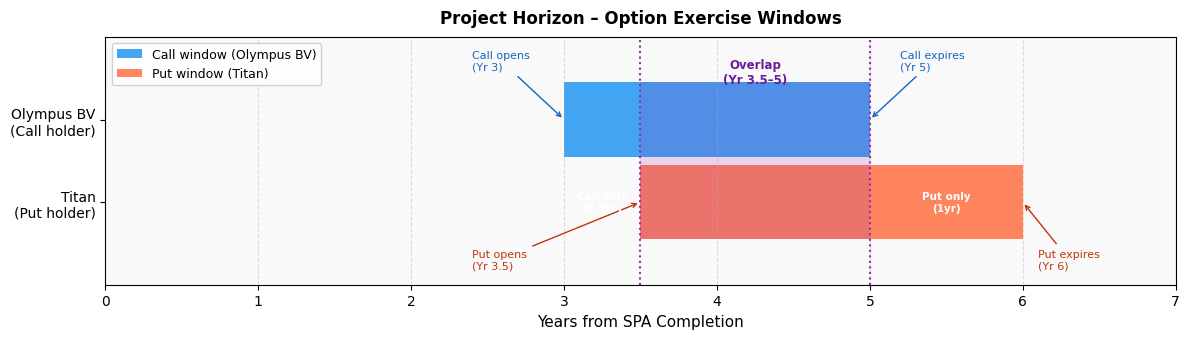

Saved: option_windows_gantt.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.set_xlim(0, 7)
ax.set_ylim(-0.5, 2.5)
ax.set_xlabel("Years from SPA Completion", fontsize=11)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["Titan\n(Put holder)", "Olympus BV\n(Call holder)"], fontsize=10)
ax.set_xticks(range(8))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')

# ── Call bar (Olympus, top row y=1) ─────────────────────────
ax.broken_barh([(3, 2)], (1.05, 0.9), facecolor='#2196F3', alpha=0.85, label='Call window (Olympus BV)')

# ── Put bar (Titan, bottom row y=0) ──────────────────────────
ax.broken_barh([(3.5, 2.5)], (0.05, 0.9), facecolor='#FF7043', alpha=0.85, label='Put window (Titan)')

# ── Overlap shading ──────────────────────────────────────────
ax.broken_barh([(3.5, 1.5)], (0.05, 1.9), facecolor='#9C27B0', alpha=0.18)
ax.axvline(3.5, color='#9C27B0', linestyle=':', linewidth=1.5)
ax.axvline(5.0, color='#9C27B0', linestyle=':', linewidth=1.5)
ax.text(4.25, 2.25, 'Overlap\n(Yr 3.5–5)', ha='center', va='top', fontsize=8.5,
        color='#6A1B9A', fontweight='bold')

# ── Annotations ──────────────────────────────────────────────
ax.annotate('Call opens\n(Yr 3)', xy=(3, 1.5), xytext=(2.4, 2.1),
            arrowprops=dict(arrowstyle='->', color='#1565C0'), fontsize=8, color='#1565C0')
ax.annotate('Call expires\n(Yr 5)', xy=(5, 1.5), xytext=(5.2, 2.1),
            arrowprops=dict(arrowstyle='->', color='#1565C0'), fontsize=8, color='#1565C0')
ax.annotate('Put opens\n(Yr 3.5)', xy=(3.5, 0.5), xytext=(2.4, -0.3),
            arrowprops=dict(arrowstyle='->', color='#BF360C'), fontsize=8, color='#BF360C')
ax.annotate('Put expires\n(Yr 6)', xy=(6, 0.5), xytext=(6.1, -0.3),
            arrowprops=dict(arrowstyle='->', color='#BF360C'), fontsize=8, color='#BF360C')

# ── "Olympus only" and "Titan only" labels ───────────────────
ax.text(3.25, 0.5, 'Call only\n(0.5yr)', ha='center', va='center', fontsize=7.5,
        color='white', fontweight='bold')
ax.text(5.5, 0.5, 'Put only\n(1yr)', ha='center', va='center', fontsize=7.5,
        color='white', fontweight='bold')

legend = ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.set_title("Project Horizon – Option Exercise Windows", fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig("option_windows_gantt.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: option_windows_gantt.png")

In [9]:
vol_range = [0.15, 0.20, 0.25, 0.30, 0.35]
rf_range  = [0.04, 0.04929, 0.06]

SIM_SENS  = 50_000
np.random.seed(42)

print(f"Net value to CCHBC (USD millions) | base case marked with *")
print(f"{'AssetVol':>9} | " + " | ".join(f"  rf={r:.2%} " for r in rf_range))
print("-" * (13 + 15 * len(rf_range)))

for vol in vol_range:
    row = []
    for rf in rf_range:
        p = np.zeros((SIM_SENS, total_steps))
        p[:, 0] = SPA_price
        for t in range(1, total_steps):
            z = np.random.standard_normal(SIM_SENS)
            p[:, t] = p[:, t-1] * np.exp(
                (rf - 0.5 * vol**2) * dt + vol * np.sqrt(dt) * z
            )
        c,  _ = lsm_bermudan_call(p, call_strike, call_start, call_end, dt, rf)
        pu, _ = lsm_bermudan_put( p, put_strike,  put_start,  put_end,  dt, rf)
        net_m  = (c - pu) * OPTION_SHARES / 1e6
        marker = " *" if (vol == 0.20 and rf == 0.04929) else "  "
        row.append(f"{net_m:>8.1f}{marker}")
    print(f"{vol:>8.0%}   | " + " | ".join(row))

Net value to CCHBC (USD millions) | base case marked with *
 AssetVol |   rf=4.00%  |   rf=4.93%  |   rf=6.00% 
----------------------------------------------------------


     15%   |     14.9   |     50.1   |     89.4  


     20%   |     13.6   |     48.1 * |     86.5  


     25%   |      7.6   |     42.5   |     82.5  


     30%   |      4.6   |     40.9   |     75.6  


     35%   |      2.5   |     39.6   |     70.8  


## 8. Extended Model: DLOM + Regulatory Risk

Two extensions to the baseline LSM that reflect real contractual features of the option agreement:

### 8a. Discount for Lack of Marketability (DLOM) — Longstaff (1995)
The option is a **private bilateral instrument** between TCCC and CCHBC — it cannot be sold, transferred, or hedged in a public market. A holder of a marketable option could sell at any time; the restricted holder cannot, and loses the ability to monetise at the peak.

**Longstaff (1995)** shows the upper bound on this illiquidity cost equals the value of a **floating-strike lookback put** — the right to sell at the highest price achieved over the restriction period T:

$$\text{DLOM}(\%) = \frac{E\left[e^{-rT}\left(\max_{0 \leq t \leq T} S_t - S_T\right)\right]}{S_0}$$

Applied here with T equal to the midpoint of the call exercise window (Year 4, central estimate) and T = 5 years (upper bound). The DLOM% is then applied to the option value: V_non-marketable = V_LSM × (1 − DLOM%).

### 8b. Regulatory Lapse Risk
Per the Option Agreement (Clause 3.2 / L62), regulatory approvals must be obtained within **12 months** of exercise notice or the exercise lapses. Required approvals include COMESA (now fully suspensory under 2025 regulations), South Africa, and other jurisdictions.

The COMESA Competition Commission has an active, unresolved investigation into TCCC's bottler agreements (Case CCC/ACBP/A.22/09/02/2024, opened October 2024) — the same agreements governing CCBA's franchise. This creates a risk that COMESA's review of the second-step option merger is delayed beyond the 12-month cap.

**Precise quantification is not possible.** We model three scenarios reflecting the state of the conduct case at the time of option exercise:

| Haircut | P(lapse) | Characterisation |
|---|---|---|
| 5% | 5% | Conduct case resolved before option exercise; second-step merger review routine |
| 15% | 15% | Conduct case partially resolved; modest delay risk on 12-month cap |
| 25% | 25% | Conduct case unresolved; COMESA managing concurrent investigation and merger review |

Model mechanics per path (applied to exercised paths where payoff > 0):
- With probability P(lapse): payoff = 0 (option lapses)
- With probability 1 − P(lapse): payoff discounted by settlement delay ~ Uniform(6, 12) months

In [10]:
# ── Step 1: Modified LSM — returns per-path discounted cash flows ──────────────

def lsm_call_per_path(paths, strike_path, window_start, window_end, dt, rf):
    """LSM Bermudan call — returns per-path discounted CFs (shape: N,)."""
    idx_start = int(window_start / dt)
    idx_end   = int(window_end   / dt)
    discount  = np.exp(-rf * dt)

    cash_flow = np.maximum(paths[:, idx_end] - strike_path[idx_end], 0)

    for step in range(idx_end - 1, idx_start - 1, -1):
        cash_flow *= discount
        intrinsic = paths[:, step] - strike_path[step]
        itm = intrinsic > 0
        if itm.sum() < 5:
            continue
        S_itm = paths[itm, step]
        X = np.column_stack([np.ones(itm.sum()), S_itm, S_itm**2, S_itm**3])
        coeffs, _, _, _ = np.linalg.lstsq(X, cash_flow[itm], rcond=None)
        exercise = intrinsic[itm] > (X @ coeffs)
        idx_itm  = np.where(itm)[0]
        cash_flow[idx_itm[exercise]] = intrinsic[itm][exercise]

    return cash_flow * np.exp(-rf * window_start)   # discounted to t=0

def lsm_put_per_path(paths, strike_path, window_start, window_end, dt, rf):
    """LSM Bermudan put — returns per-path discounted CFs (shape: N,)."""
    idx_start = int(window_start / dt)
    idx_end   = int(window_end   / dt)
    discount  = np.exp(-rf * dt)

    cash_flow = np.maximum(strike_path[idx_end] - paths[:, idx_end], 0)

    for step in range(idx_end - 1, idx_start - 1, -1):
        cash_flow *= discount
        intrinsic = strike_path[step] - paths[:, step]
        itm = intrinsic > 0
        if itm.sum() < 5:
            continue
        S_itm = paths[itm, step]
        X = np.column_stack([np.ones(itm.sum()), S_itm, S_itm**2, S_itm**3])
        coeffs, _, _, _ = np.linalg.lstsq(X, cash_flow[itm], rcond=None)
        exercise = intrinsic[itm] > (X @ coeffs)
        idx_itm  = np.where(itm)[0]
        cash_flow[idx_itm[exercise]] = intrinsic[itm][exercise]

    return cash_flow * np.exp(-rf * window_start)

# Run base LSM and retain per-path cash flows
np.random.seed(42)
cf_call = lsm_call_per_path(paths, call_strike, call_start, call_end, dt, risk_free_rate)
cf_put  = lsm_put_per_path( paths, put_strike,  put_start,  put_end,  dt, risk_free_rate)

# Sanity-check: should match Section 6
print(f"Call (per share, check): {cf_call.mean():.4f}  [ref: {call_value_per_share:.4f}]")
print(f"Put  (per share, check): {cf_put.mean():.4f}  [ref: {put_value_per_share:.4f}]")

Call (per share, check): 118.1812  [ref: 118.1812]
Put  (per share, check): 86.6643  [ref: 86.6643]


In [11]:
# ── Step 2: DLOM — Longstaff (1995) lookback put via Monte Carlo ───────────────
#
# The floating-strike lookback put payoff:
#   payoff = max(S_t, t in [0,T]) - S_T
# Its PV = e^{-rT} * E[payoff]  gives the upper bound on the cost of illiquidity.
# DLOM% = V_lookback / S_0
# Applied to option: V_non-marketable = V_LSM * (1 - DLOM%)
#
# Restriction periods:
#   T = 3.0yr  →  lower bound (earliest exercise)
#   T = 4.0yr  →  central estimate (midpoint of call window)
#   T = 5.0yr  →  upper bound   (latest call exercise)

dlom_results = {}
for T_r in [3.0, 4.0, 5.0]:
    idx_T = int(T_r / dt)
    S_max = paths[:, :idx_T + 1].max(axis=1)        # max over [0, T_r]
    S_end = paths[:, idx_T]                           # S at T_r
    lookback_payoff = S_max - S_end                   # always >= 0
    V_lookback = np.exp(-risk_free_rate * T_r) * lookback_payoff.mean()
    dlom_pct   = V_lookback / SPA_price
    dlom_results[T_r] = dlom_pct
    print(f"T = {T_r:.1f}yr | Lookback put value: {V_lookback:7.3f} | DLOM% = {dlom_pct:.2%}")

dlom_central = dlom_results[4.0]
dlom_upper   = dlom_results[5.0]
print(f"\nDLOM applied (central, T=4yr): {dlom_central:.2%}")
print(f"DLOM applied (upper,   T=5yr): {dlom_upper:.2%}")

T = 3.0yr | Lookback put value: 108.052 | DLOM% = 18.72%


T = 4.0yr | Lookback put value: 121.871 | DLOM% = 21.11%


T = 5.0yr | Lookback put value: 133.056 | DLOM% = 23.05%

DLOM applied (central, T=4yr): 21.11%
DLOM applied (upper,   T=5yr): 23.05%


In [ ]:
# ── Regulatory Lapse Sensitivity — FOR REFERENCE ONLY ─────────────────────────
#
# The Option Agreement (Clause 3.2 / L62) contains a 12-month cap on obtaining
# merger control approvals for the option exercise. If approvals are not obtained
# within 12 months of exercise notice, the exercise lapses.
#
# This sensitivity is documented but NOT applied to the primary valuation.
# The risk is assessed as theoretical only:
#   - COMESA conduct case expected to result in minor franchise amendment only
#     (passive sales carve-out, consistent with Heineken/Diageo precedents)
#   - TCCC as 25% post-close owner has fully aligned incentives to resolve the
#     conduct case and cooperate on approvals
#   - Second-step merger filing expected to be routine once conduct case settled
#
# See Project_Horizon_Regulatory_Risk.md Section 4 for full rationale.
#
# Three illustrative P(lapse) scenarios shown for sensitivity reference:
#   5%  — conduct case resolved; routine second-step review
#   15% — partially resolved; modest delay risk
#   25% — unresolved; concurrent conduct + merger review (stress only)

def apply_regulatory(cf_paths, p_lapse, rf, seed=99):
    rng = np.random.default_rng(seed)
    exercised = cf_paths > 0
    u_lapse   = rng.uniform(0, 1, len(cf_paths))
    u_delay   = rng.uniform(6/12, 12/12, len(cf_paths))
    lapsed    = exercised & (u_lapse < p_lapse)
    delayed   = exercised & ~lapsed
    cf_adj    = cf_paths.copy()
    cf_adj[lapsed]  = 0.0
    cf_adj[delayed] *= np.exp(-rf * u_delay[delayed])
    return cf_adj

print("Primary valuation (DLOM applied — regulatory risk not applied)")
print("=" * 65)
dlom = dlom_central
net_base = (cf_call.mean() - cf_put.mean()) * OPTION_SHARES / 1e6
net_dlom = (cf_call.mean() * (1-dlom) - cf_put.mean() * (1-dlom)) * OPTION_SHARES / 1e6
print(f"  LSM baseline (marketable):          USD {net_base:.1f}M")
print(f"  LSM + DLOM {dlom:.1%} (non-marketable):  USD {net_dlom:.1f}M  ← primary estimate")
print()
print("Regulatory lapse sensitivity (reference only — not applied)")
print("=" * 65)
for p in [0.05, 0.15, 0.25]:
    cc = apply_regulatory(cf_call, p, risk_free_rate) * (1-dlom)
    cp = apply_regulatory(cf_put,  p, risk_free_rate) * (1-dlom)
    net = (cc.mean() - cp.mean()) * OPTION_SHARES / 1e6
    print(f"  DLOM {dlom:.1%} + P(lapse)={p:.0%}:              USD {net:.1f}M")